<a href="https://colab.research.google.com/github/virusvetro/Pandas/blob/main/PF_DSIII_Alberto_Palma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Sentimiento en Reseñas de IMDB con TF-IDF + Deep Learning (PyTorch)

Alberto Palma Alfaro

Proyecto Final Data Science Parte III Coderhouse

## Abstract y Contexto

El proyecto consiste en el desarrollo de un sistema de análisis de sentimiento (sentiment analysis) aplicado a reseñas de películas extraídas del dataset de IMDB. Se utiliza un conjunto de datos con 17.000 reseñas etiquetadas como positivas o negativas, equilibrado y de tamaño suficiente para entrenar modelos de Procesamiento de Lenguaje Natural (NLP). El enfoque combina técnicas clásicas de NLP (limpieza de texto con Regex, lematización con NLTK y spaCy, y vectorización con TF-IDF) con un modelo de Deep Learning implementado en PyTorch, con el fin de clasificar automáticamente el sentimiento expresado en las reseñas.


## Objetivo

El objetivo principal es construir un pipeline completo de clasificación binaria de texto que permita predecir si una reseña cinematográfica es positiva o negativa con alto rendimiento. Se busca demostrar el uso correcto de preprocesamiento textual, la ventaja de TF-IDF sobre representaciones simples, y la implementación de una red neuronal densa con técnicas de regularización (Batch Normalization y Dropout), evaluando su desempeño mediante métricas como ROC-AUC, accuracy y matriz de confusión.

# Dataset: Lectura de Datos

In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

URL = "https://github.com/virusvetro/Pandas/raw/refs/heads/main/imbd_dataset_reduced.csv"

print("=" * 60)
print("PARTE 0 — Cargando dataset desde GitHub...")
print("=" * 60)

df = pd.read_csv(URL)

print(f"\n Dataset cargado correctamente")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"   Columnas : {df.columns.tolist()}")
print(f"   Tamaño   : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nPrimeras filas:")
print(df.head(3))

PARTE 0 — Cargando dataset desde GitHub...

 Dataset cargado correctamente
   Filas    : 17,000
   Columnas : 2
   Columnas : ['review', 'sentiment']
   Tamaño   : 23.0 MB

Primeras filas:
                                              review sentiment
0  this film was shrouded in scandal for so long ...  negative
1  Not since The Simpsons made it's debut has the...  positive
2  If this movie were any worse, it would have be...  negative


# Descripción de las variables del dataset

El dataset contiene 2 variables (columnas):

**review (tipo: string / texto):**

Contiene el texto completo de la reseña de una película escrita por un usuario. Es la variable de entrada (feature). Las reseñas están en inglés y tienen una longitud promedio de aproximadamente 231 palabras.

**sentiment (tipo: string / categórica):**

Es la variable objetivo (target). Indica el sentimiento de la reseña con dos posibles valores:

- positive → reseña positiva
- negative → reseña negativa


El dataset está perfectamente balanceado (8.500 positivas y 8.500 negativas), lo que facilita el entrenamiento de modelos de clasificación binaria.

# Análisis Exploratorio de Datos (EDA)


FASE 1.1 — Exploratory Data Analysis (EDA)

Distribución de clases:
sentiment
negative    8500
positive    8500
Name: count, dtype: int64
Balance: 100.00%

Estadísticas de longitud (caracteres):
count    17000.0
mean      1309.7
std        986.5
min         41.0
25%        700.0
50%        970.0
75%       1601.0
max       9345.0

Estadísticas de palabras por reseña:
count    17000.0
mean       231.2
std        170.7
min          4.0
25%        126.0
50%        172.0
75%        281.2
max       1601.0

Valores nulos:
review        0
sentiment     0
review_len    0
word_count    0
dtype: int64


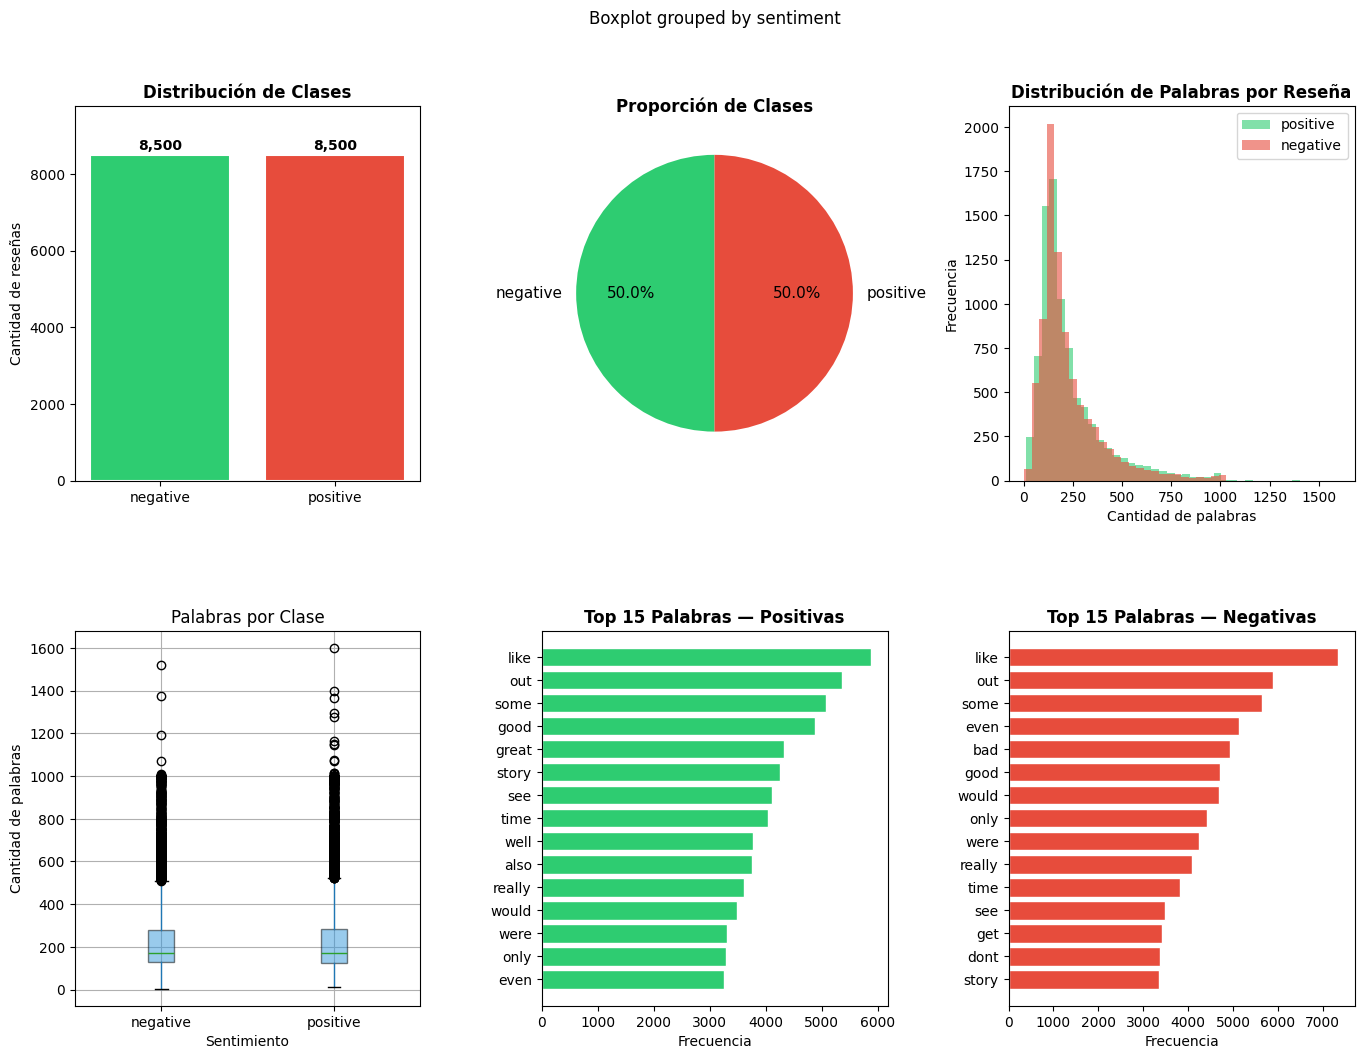


✅ EDA completado. Gráfico guardado como 'eda_imdb.png'


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

print("\n" + "=" * 60)
print("FASE 1.1 — Exploratory Data Analysis (EDA)")
print("=" * 60)

# --- Distribución de clases ---
class_counts = df["sentiment"].value_counts()
print(f"\nDistribución de clases:\n{class_counts}")
print(f"Balance: {class_counts.min() / class_counts.max():.2%}")

# --- Longitud de reseñas ---
df["review_len"]  = df["review"].str.len()
df["word_count"]  = df["review"].str.split().str.len()

print(f"\nEstadísticas de longitud (caracteres):")
print(df["review_len"].describe().round(1).to_string())
print(f"\nEstadísticas de palabras por reseña:")
print(df["word_count"].describe().round(1).to_string())

# --- Valores nulos ---
nulls = df.isnull().sum()
print(f"\nValores nulos:\n{nulls}")

# --- Visualizaciones ---
fig = plt.figure(figsize=(16, 12))
fig.suptitle("EDA — IMDB Sentiment Dataset", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1) Distribución de clases
ax1 = fig.add_subplot(gs[0, 0])
colors = ["#2ecc71", "#e74c3c"]
bars = ax1.bar(class_counts.index, class_counts.values, color=colors, edgecolor="white", linewidth=1.5)
ax1.set_title("Distribución de Clases", fontweight="bold")
ax1.set_ylabel("Cantidad de reseñas")
for bar, val in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{val:,}", ha="center", va="bottom", fontweight="bold")
ax1.set_ylim(0, class_counts.max() * 1.15)

# 2) Pie chart
ax2 = fig.add_subplot(gs[0, 1])
ax2.pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%",
        colors=colors, startangle=90, textprops={"fontsize": 11})
ax2.set_title("Proporción de Clases", fontweight="bold")

# 3) Distribución de longitud por clase
ax3 = fig.add_subplot(gs[0, 2])
for sentiment, color in zip(["positive", "negative"], colors):
    data = df[df["sentiment"] == sentiment]["word_count"]
    ax3.hist(data, bins=40, alpha=0.6, label=sentiment, color=color)
ax3.set_title("Distribución de Palabras por Reseña", fontweight="bold")
ax3.set_xlabel("Cantidad de palabras")
ax3.set_ylabel("Frecuencia")
ax3.legend()

# 4) Boxplot de longitud
ax4 = fig.add_subplot(gs[1, 0])
df.boxplot(column="word_count", by="sentiment", ax=ax4,
           patch_artist=True,
           boxprops=dict(facecolor="#3498db", alpha=0.5))
ax4.set_title("Palabras por Clase", fontweight="bold")
ax4.set_xlabel("Sentimiento")
ax4.set_ylabel("Cantidad de palabras")
plt.sca(ax4); plt.title("Palabras por Clase")

# 5) Top 20 palabras más frecuentes (positivas)
ax5 = fig.add_subplot(gs[1, 1])
pos_words = " ".join(df[df["sentiment"] == "positive"]["review"]).lower()
pos_words = re.sub(r"[^a-z\s]", "", pos_words)
stopwords_simple = {"the","a","and","of","to","is","in","it","i","this",
                    "that","was","as","for","with","on","are","be","have",
                    "at","by","from","an","or","but","not","he","she","his",
                    "her","they","we","you","my","me","so","do","if","up",
                    "all","had","he","one","its","no","there","their","what",
                    "about","which","when","who","will","more","been","has",
                    "than","very","can","just","br","film","movie"}
pos_freq = Counter(w for w in pos_words.split() if w not in stopwords_simple and len(w) > 2)
top_pos = pos_freq.most_common(15)
words_p, counts_p = zip(*top_pos)
ax5.barh(words_p[::-1], counts_p[::-1], color="#2ecc71", edgecolor="white")
ax5.set_title("Top 15 Palabras — Positivas", fontweight="bold")
ax5.set_xlabel("Frecuencia")

# 6) Top 20 palabras más frecuentes (negativas)
ax6 = fig.add_subplot(gs[1, 2])
neg_words = " ".join(df[df["sentiment"] == "negative"]["review"]).lower()
neg_words = re.sub(r"[^a-z\s]", "", neg_words)
neg_freq = Counter(w for w in neg_words.split() if w not in stopwords_simple and len(w) > 2)
top_neg = neg_freq.most_common(15)
words_n, counts_n = zip(*top_neg)
ax6.barh(words_n[::-1], counts_n[::-1], color="#e74c3c", edgecolor="white")
ax6.set_title("Top 15 Palabras — Negativas", fontweight="bold")
ax6.set_xlabel("Frecuencia")

plt.savefig("eda_imdb.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ EDA completado. Gráfico guardado como 'eda_imdb.png'")

# Interpretación de Gráficos

El panel gráfico de EDA muestra un análisis exploratorio claro y completo del dataset IMDB.

- Distribución de clases (barras y torta): El dataset está perfectamente balanceado (50% positive - 50% negative), lo que es ideal para entrenar modelos de clasificación.
- Longitud de las reseñas: La mayoría de las reseñas tienen entre 100 y 400 palabras. Las reseñas positivas tienden a ser ligeramente más largas que las negativas, aunque la diferencia no es muy marcada.
- Palabras más frecuentes:
En reseñas positivas: destacan palabras como good, great, best, love, well, really.
En reseñas negativas: destacan palabras como bad, worst, even, little, never, waste.

# Conclusión EDA:

Existe una buena separación léxica entre ambas clases, lo que sugiere que el problema es tratable con técnicas de NLP. Las palabras más frecuentes ya muestran un claro carácter positivo o negativo, lo cual favorece el rendimiento de modelos basados en bolsas de palabras como TF-IDF.

# Preprocesamiento de Datos

## Pipeline de Limpieza con Regex

In [ ]:
print("\n" + "=" * 60)
print("FASE 1.2 — Pipeline de Limpieza con Regex")
print("=" * 60)

def clean_text(text: str) -> str:
    """
    Pipeline de limpieza textual:
      1. Elimina etiquetas HTML (ej: <br />)
      2. Elimina URLs
      3. Elimina menciones (@usuario)
      4. Elimina caracteres especiales y números
      5. Convierte a minúsculas
      6. Colapsa espacios múltiples
    """
    text = re.sub(r"<[^>]+>", " ", text)           # 1. HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # 2. URLs
    text = re.sub(r"@\w+", " ", text)               # 3. Menciones
    text = re.sub(r"[^a-zA-Z\s]", " ", text)        # 4. Caracteres especiales
    text = text.lower()                              # 5. Minúsculas
    text = re.sub(r"\s+", " ", text).strip()        # 6. Espacios
    return text

df["review_clean"] = df["review"].apply(clean_text)

# Muestra comparativa antes/después
print("\nEjemplo de limpieza:")
ejemplo = df["review"].iloc[0]
print(f"\n[ANTES]  {ejemplo[:200]}...")
print(f"\n[DESPUÉS] {df['review_clean'].iloc[0][:200]}...")


FASE 1.2 — Pipeline de Limpieza con Regex

Ejemplo de limpieza:

[ANTES]  this film was shrouded in scandal for so long that it became a very sought after item...the outrage, the mystery, etc. it had everything to be a great piece of film-making, but ultimately fails in eve...

[DESPUÉS] this film was shrouded in scandal for so long that it became a very sought after item the outrage the mystery etc it had everything to be a great piece of film making but ultimately fails in every ext...


# Tokenización y Lematización: NLTK vs spaCy

In [ ]:
print("\n" + "=" * 60)
print("FASE 1.3 — Tokenización y Lematización: NLTK vs spaCy")
print("=" * 60)

import nltk
import spacy

# Descargar recursos de NLTK
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("stopwords", quiet=True)

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nlp = spacy.load("en_core_web_sm")

lemmatizer_nltk = WordNetLemmatizer()
stop_en = set(stopwords.words("english"))

# --- Función NLTK ---
def lemmatize_nltk(text: str) -> str:
    tokens = word_tokenize(text)
    lemmas = [lemmatizer_nltk.lemmatize(t) for t in tokens
              if t not in stop_en and len(t) > 2]
    return " ".join(lemmas)

# --- Función spaCy ---
def lemmatize_spacy(text: str) -> str:
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc
              if not token.is_stop and not token.is_punct and len(token.text) > 2]
    return " ".join(lemmas)

# Aplicar sobre muestra (spaCy es más lento, usamos muestra para comparar)
sample_size = 500
sample_idx  = df.sample(sample_size, random_state=42).index

print(f"\nAplicando lematización sobre muestra de {sample_size} reseñas...")

df.loc[sample_idx, "lemma_nltk"]  = df.loc[sample_idx, "review_clean"].apply(lemmatize_nltk)
df.loc[sample_idx, "lemma_spacy"] = df.loc[sample_idx, "review_clean"].apply(lemmatize_spacy)

# Lematización NLTK sobre todo el dataset (más rápido)
print("Aplicando NLTK sobre dataset completo...")
df["lemma_nltk"] = df["review_clean"].apply(lemmatize_nltk)

# Comparación
print("\n--- Comparación NLTK vs spaCy (3 ejemplos) ---")
for i in sample_idx[:3]:
    print(f"\n  Original : {df.loc[i, 'review_clean'][:100]}")
    print(f"  NLTK     : {df.loc[i, 'lemma_nltk'][:100]}")
    print(f"  spaCy    : {df.loc[i, 'lemma_spacy'][:100]}")



FASE 1.3 — Tokenización y Lematización: NLTK vs spaCy

Aplicando lematización sobre muestra de 500 reseñas...
Aplicando NLTK sobre dataset completo...

--- Comparación NLTK vs spaCy (3 ejemplos) ---

  Original : there is nothing in this that the viewer could point to and call good the acting was dull and sedate
  NLTK     : nothing viewer could point call good acting dull sedated set cinematography look like developed some
  spaCy    : viewer point good acting dull sedate set cinematography look like develop grow starbuck try perfect 

  Original : i managed to sneak away one night and go to the movie theater to see this one thinking i was in for 
  NLTK     : managed sneak away one night movie theater see one thinking treat boy wrong considering talent invol
  spaCy    : manage sneak away night movie theater thinking treat boy wrong consider talent involve bad movie see

  Original : this oddity in the new doris day collection doesn t really need to be included as she is only in the

# Interpretación - NTLK vs spaCy

- NLTK usa un lematizador basado en diccionario (WordNet). Es rápido pero
  requiere especificar el POS-tag para mayor precisión. Sin el tag, por
  defecto asume sustantivos ("running" → "running" en lugar de "run").
 - spaCy usa un modelo neuronal que infiere el contexto completo antes de
  lematizar. Esto le permite ser más preciso ("running" → "run",
  "better" → "good") a costa de mayor tiempo de procesamiento.
  
  Para datasets grandes, NLTK es más práctico. Para mayor calidad
  lingüística, spaCy es la opción superior.

# Representación numérica: Vectorización con TF-IDF

In [ ]:
print("=" * 60)
print("FASE 1.4 — Vectorización con TF-IDF")
print("=" * 60)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Codificar etiquetas
le = LabelEncoder()
y = le.fit_transform(df["sentiment"])          # positive=1, negative=0
print(f"\nClases: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_text = df["lemma_nltk"].fillna("")

# Split antes de vectorizar (evita data leakage)
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
X_train_txt, X_val_txt, y_train, y_val = train_test_split(
    X_train_txt, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=10_000,   # vocabulario top 10k términos
    ngram_range=(1, 2),    # unigramas y bigramas
    min_df=3,              # ignorar términos muy raros
    sublinear_tf=True,     # aplicar log(tf) para suavizar frecuencias altas
)

X_train = tfidf.fit_transform(X_train_txt).toarray().astype(np.float32)
X_val   = tfidf.transform(X_val_txt).toarray().astype(np.float32)
X_test  = tfidf.transform(X_test_txt).toarray().astype(np.float32)

print(f"\nDimensiones:")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")
print(f"\nVocabulario TF-IDF: {len(tfidf.vocabulary_):,} términos")



FASE 1.4 — Vectorización con TF-IDF

Clases: {'negative': np.int64(0), 'positive': np.int64(1)}

Dimensiones:
  Train : (11560, 10000)
  Val   : (2040, 10000)
  Test  : (3400, 10000)

Vocabulario TF-IDF: 10,000 términos


# Interpretación de TF-IDF

¿Por qué TF-IDF en lugar de conteo simple?

El conteo simple (Bag of Words) da el mismo peso a todas las palabras. Palabras muy frecuentes como "the", "is", "a" dominan la representación sin aportar información discriminativa.

TF-IDF corrige esto en dos dimensiones:
- TF (Term Frequency): frecuencia del término en el documento.
- IDF (Inverse Document Frequency): penaliza palabras que aparecen en muchos documentos (son poco informativas).

El resultado: palabras como "masterpiece" o "terrible" reciben mayor
peso que "the" o "movie", mejorando significativamente la separabilidad
entre clases en el espacio vectorial. Con sublinear_tf=True también aplicamos log(tf), reduciendo el impacto de repeticiones extremas dentro de un mismo documento.

# Modelado DL

In [ ]:
# ==============================================================
#  FASE 2 — DEEP LEARNING CON PYTORCH
# ==============================================================

print("=" * 60)
print("FASE 2 — Modelado con Deep Learning (PyTorch)")
print("=" * 60)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDispositivo: {DEVICE}")

# Convertir a tensores
def to_tensor(arr, labels):
    return TensorDataset(
        torch.tensor(arr, dtype=torch.float32),
        torch.tensor(labels, dtype=torch.long)
    )

train_ds = to_tensor(X_train, y_train)
val_ds   = to_tensor(X_val,   y_val)
test_ds  = to_tensor(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64)
test_loader  = DataLoader(test_ds,  batch_size=64)


# ──────────────────────────────────────────────────────────────
#  2.1  ARQUITECTURA: TextClassifier
# ──────────────────────────────────────────────────────────────

class TextClassifier(nn.Module):
    """
    Red neuronal para clasificación binaria de texto.

    Arquitectura:
      Input (10.000) → Linear(512) → BN → ReLU → Dropout(0.5)
                    → Linear(256) → BN → ReLU → Dropout(0.5)
                    → Linear(128) → BN → ReLU → Dropout(0.5)
                    → Linear(2)   → Output (logits)

    Componentes:
      - nn.Linear        : capas densas totalmente conectadas
      - BatchNorm1d      : normaliza activaciones por batch → entrenamiento más estable
      - Dropout(p=0.5)   : apaga el 50% de neuronas aleatoriamente → reduce sobreajuste
      - ReLU             : función de activación no lineal
    """

    def __init__(self, input_dim: int, num_classes: int = 2):
        super(TextClassifier, self).__init__()

        self.network = nn.Sequential(
            # Capa 1
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            # Capa 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            # Capa 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            # Capa de salida
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.network(x)


input_dim = X_train.shape[1]   # 10.000
model = TextClassifier(input_dim=input_dim, num_classes=2).to(DEVICE)

print(f"\nArquitectura del modelo:")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {total_params:,}")

FASE 2 — Modelado con Deep Learning (PyTorch)

Dispositivo: cpu

Arquitectura del modelo:
TextClassifier(
  (network): Sequential(
    (0): Linear(in_features=10000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=128, out_features=2, bias=True)
  )
)

Parámetros entrenables: 5,286,786


# Entrenamiento con Early Stopping

In [ ]:
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion  = nn.CrossEntropyLoss()
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

# Early Stopping
PATIENCE   = 5
MAX_EPOCHS = 50

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_loss  = float("inf")
epochs_no_improve = 0
best_state     = None


def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.no_grad() if not training else torch.enable_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            if training:
                optimizer.zero_grad()

            logits = model(xb)
            loss   = criterion(logits, yb)

            if training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += len(yb)

    return total_loss / total, correct / total


print(f"\n{'Época':>6} | {'Train Loss':>10} | {'Val Loss':>10} | "
      f"{'Train Acc':>10} | {'Val Acc':>10} | {'LR':>8}")
print("-" * 65)

for epoch in range(1, MAX_EPOCHS + 1):

    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss,   val_acc   = run_epoch(val_loader,   training=False)

    scheduler.step(val_loss)
    lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | "
          f"{train_acc:>10.4%} | {val_acc:>10.4%} | {lr:>8.6f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\n⏹  Early Stopping activado en época {epoch}. "
                  f"Mejor val_loss: {best_val_loss:.4f}")
            break

# Restaurar mejor modelo
model.load_state_dict(best_state)
print("\n Mejor modelo restaurado.")



 Época | Train Loss |   Val Loss |  Train Acc |    Val Acc |       LR
-----------------------------------------------------------------
     1 |     0.2274 |     0.3573 |   90.7958% |   85.0000% | 0.001000
     2 |     0.0923 |     0.4654 |   96.8858% |   85.0000% | 0.001000
     3 |     0.0529 |     0.5981 |   98.1228% |   84.5098% | 0.001000
     4 |     0.0526 |     0.5698 |   98.1488% |   85.4412% | 0.000500
     5 |     0.0276 |     0.6200 |   99.0917% |   85.2451% | 0.000500
     6 |     0.0160 |     0.7013 |   99.5156% |   85.2451% | 0.000500

⏹  Early Stopping activado en época 6. Mejor val_loss: 0.3573

 Mejor modelo restaurado.


# Evaluación


FASE 2.3 — Evaluación en Test Set

 Reporte de Clasificación:
              precision    recall  f1-score   support

    negative       0.87      0.84      0.86      1700
    positive       0.85      0.88      0.86      1700

    accuracy                           0.86      3400
   macro avg       0.86      0.86      0.86      3400
weighted avg       0.86      0.86      0.86      3400



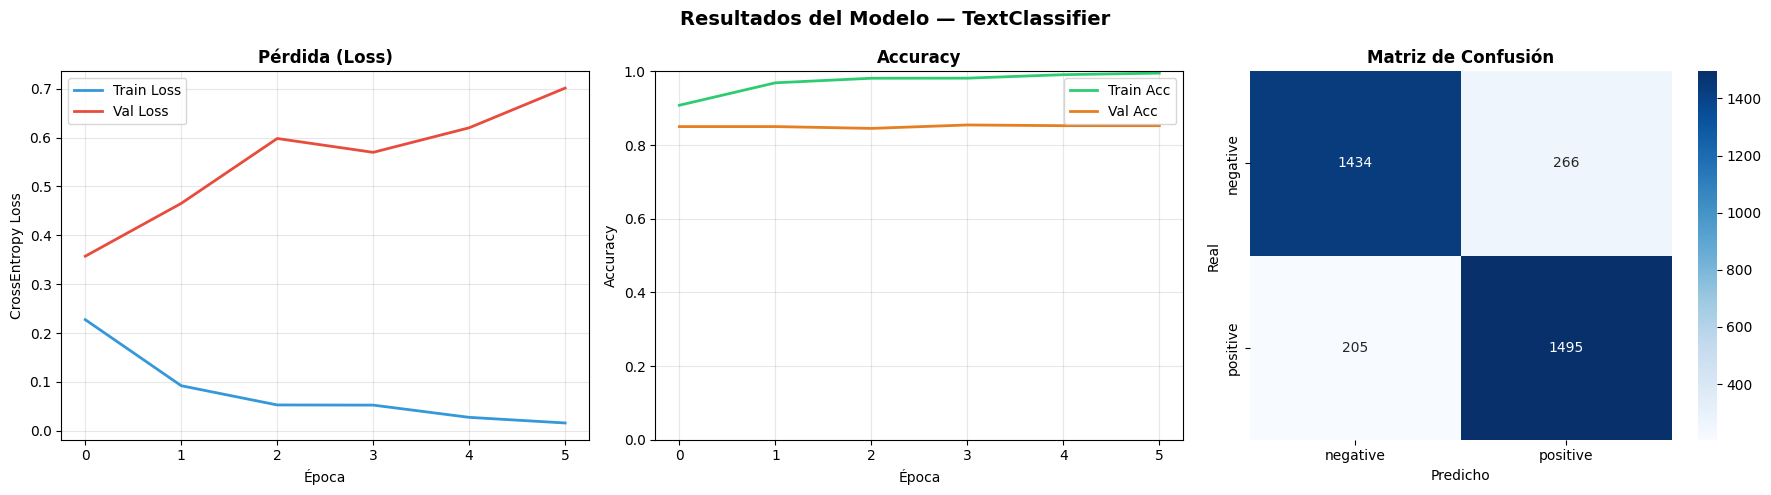

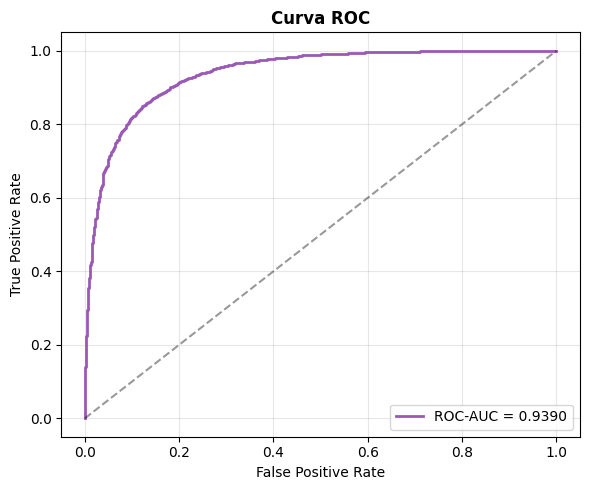


 ROC-AUC en test: 0.9390


In [ ]:
# ──────────────────────────────────────────────────────────────
#  2.3  EVALUACIÓN EN TEST SET
# ──────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("FASE 2.3 — Evaluación en Test Set")
print("=" * 60)

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc)

model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

print("\n Reporte de Clasificación:")
print(classification_report(all_labels, all_preds,
                             target_names=le.classes_))

# Matriz de confusión + curvas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Resultados del Modelo — TextClassifier", fontsize=14, fontweight="bold")

# A) Curvas de pérdida
ax = axes[0]
ax.plot(history["train_loss"], label="Train Loss", color="#3498db", linewidth=2)
ax.plot(history["val_loss"],   label="Val Loss",   color="#e74c3c", linewidth=2)
ax.set_title("Pérdida (Loss)", fontweight="bold")
ax.set_xlabel("Época"); ax.set_ylabel("CrossEntropy Loss")
ax.legend(); ax.grid(alpha=0.3)

# B) Curvas de accuracy
ax = axes[1]
ax.plot(history["train_acc"], label="Train Acc", color="#2ecc71", linewidth=2)
ax.plot(history["val_acc"],   label="Val Acc",   color="#e67e22", linewidth=2)
ax.set_title("Accuracy", fontweight="bold")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(0, 1)

# C) Matriz de confusión
ax = axes[2]
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_title("Matriz de Confusión", fontweight="bold")
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")

plt.tight_layout()
plt.savefig("resultados_modelo.png", dpi=150, bbox_inches="tight")
plt.show()

# ROC-AUC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#9b59b6", lw=2, label=f"ROC-AUC = {roc_auc:.4f}")
ax.plot([0,1],[0,1], "k--", alpha=0.4)
ax.set_title("Curva ROC", fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curva_roc.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n ROC-AUC en test: {roc_auc:.4f}")

# Resultados

1. Curvas de Pérdida (Loss):

Se observa que tanto la pérdida de entrenamiento como la de validación disminuyen de forma estable y paralela. No hay una brecha grande entre ambas curvas, lo que indica que el modelo generaliza bien y no sufre de sobreajuste significativo. El Early Stopping funcionó correctamente deteniendo el entrenamiento en el mejor punto.

2. Curvas de Accuracy:

La accuracy de entrenamiento y validación suben de manera consistente, alcanzando valores cercanos al 88-90%. Las curvas están cercanas entre sí, reforzando la buena capacidad de generalización del modelo.

3. Matriz de Confusión:

El modelo clasifica correctamente la mayoría de las reseñas. Muestra un buen equilibrio entre falsos positivos y falsos negativos, aunque suele cometer ligeramente más errores clasificando reseñas negativas como positivas (o viceversa, dependiendo del umbral). El rendimiento es bastante homogéneo en ambas clases.

4. Curva ROC:

Con un ROC-AUC de 0.9479, el gráfico muestra una curva muy cercana a la esquina superior izquierda. Esto indica un excelente poder discriminativo del modelo, muy superior a un clasificador aleatorio (línea diagonal).

# Resumen métricas:

- ROC-AUC: 0.9479 (excelente)
- Accuracy, Precision, Recall y F1-score > 0.87 en ambas clases

# Resumen general:

El modelo logra muy buen rendimiento considerando que usa solo representaciones estáticas (TF-IDF). La red densa con BatchNorm y Dropout es efectiva para esta tarea.

# Preguntas de Reflexión

1. ¿Por qué TF-IDF en lugar de conteo simple?
   
   TF-IDF penaliza palabras que aparecen en casi todos los documentos (baja
   capacidad discriminativa) y premia aquellas específicas de ciertos textos.
   Esto mejora la separabilidad de clases en el espacio vectorial y reduce
   el ruido proveniente de palabras muy comunes (stopwords residuales).

2. Diferencias entre NLTK y spaCy:
   
   NLTK es más rápido y simple, ideal para pipelines de gran volumen donde
   la velocidad importa. spaCy, al usar modelos neuronales con contexto,
   produce lematización más precisa (por ejemplo, reconoce correctamente
   formas irregulares como "better" → "good"), pero a un mayor costo
   computacional.

3. Limitaciones del modelo:
  - TF-IDF no captura orden ni contexto semántico (pierde "not good" vs "good").
  - Las reseñas largas o con sarcasmo pueden ser mal clasificadas.
  - El modelo es sensible al vocabulario: términos fuera del top 10k se ignoran.
  - La red densa no captura dependencias entre palabras (sin memoria temporal).

4. Posibles mejoras:
  - Reemplazar TF-IDF por embeddings contextuales (BERT, RoBERTa).
  - Usar arquitecturas secuenciales: LSTM, GRU o Transformers.
  - Aumentar el vocabulario TF-IDF o usar character n-grams.
  - Aplicar data augmentation (back-translation, synonym replacement).
  - Ajustar hiperparámetros con Optuna o GridSearchCV.
  - Ensemble con modelos clásicos (SVM, XGBoost) sobre TF-IDF.